In [2]:
import requests
import pandas as pd
import psycopg2
from tqdm import tqdm

# Конфигурация подключения к БД
DB_CONFIG = {
    "host": "10.0.0.3",
    "port": 5435,
    "database": "medical_db",
    "user": "medical_user",
    "password": "medical_password"
}

# Конфигурация API
API_URL = "http://localhost:8000/api/search"
THRESHOLD = 0.0  # получаем все результаты

# 1. Получаем все round_id из таблицы medical_rounds
# conn = psycopg2.connect(**DB_CONFIG)
# cur = conn.cursor()
# cur.execute("SELECT id, reg_id, descr FROM medical_rounds ORDER BY id")
# rows = cur.fetchall()
# cur.close()
# conn.close()

# all_rounds = pd.DataFrame(rows, columns=["round_id", "reg_id", "descr"])
# print(f"Всего записей в БД: {len(all_rounds)}")
# all_rounds


In [13]:
all_rounds = pd.read_parquet("rounds_from_db_clean.parquet")
all_rounds

,round_id,reg_id,descr
0,1,4916428980535602061,Обход совместно с: зав. отделением ТКМ для взр...
1,2,3134398391787225792,Обход совместно с: директором НИИ ДОГиТ им. Р....
2,3,2356037514002751612,Обход совместно с: заместителем директора по н...
3,4,6334594449636287523,"Обход совместно с: к.м.н., главным детским онк..."
4,5,7428038284915799600,Обход совместно с: руководителем отдела онколо...
...,...,...,...
95,96,4141580952927286256,Обход совместно с: зам. директора НИИДОГиТ по ...
96,97,15319540792583192730,Обход совместно с: директором НИИ ДОГиТ им. Р....
97,98,10095121539069619342,Обход совместно с: зам. директора НИИДОГиТ по ...
98,99,9223443311416430315,Обход совместно с: директором НИИ ДОГиТ им. Р....


In [ ]:
queries = [
    "пациенты с анемией и мукозитом",
    "пациенты с лейкозом, принимавшие антибиотики",
    "пациенты получившие алло-ТГСК и протокол Flu+Bu",
    "пациенты с острым миелоидным лейкозом  и делецией короткого плеча 12-ой хромосомы",
    "пациенты с РТПХ кожи принимавшие флударабин и бусульфан"
]


## MY APPROACH

In [ ]:

scores_dict = {q: {} for q in queries}

for query in tqdm(queries, desc="Processing queries"):
    response = requests.post(
        API_URL,
        json={"query": query},
        params={"threshold": THRESHOLD}
    )
    response.raise_for_status()
    data = response.json()
    for res in data['results']:
        round_id = res['round_id']
        score = res['score']
        scores_dict[query][round_id] = score


result_df = all_rounds[['round_id', 'reg_id', 'descr']].copy()
for query in queries:
    col_name = f"score_{query[:30].replace(' ', '_')}"
    result_df[col_name] = result_df['round_id'].apply(lambda rid: scores_dict[query].get(rid, 0.0))

result_df.to_parquet("queries3res.parquet")
print("Результаты сохранены в queries3res.parquet")
print(result_df.head())

In [5]:
result_df = pd.read_parquet("queries5res_clean.parquet")
result_df

,round_id,reg_id,descr,score_пациенты_с_анемией_и_мукозитом,"score_пациенты_с_лейкозом,_принимавш",score_пациенты_получившие_алло-ТГСК_,score_пациенты_с_острым_миелоидным_л,score_пациенты_с_РТПХ_кожи_принимавш
0,1,4916428980535602061,Обход совместно с: зав. отделением ТКМ для взр...,0.500000,0.864564,0.000000,0.458252,0.000000
1,2,3134398391787225792,Обход совместно с: директором НИИ ДОГиТ им. Р....,0.000000,0.431488,0.000000,0.439222,0.606674
2,3,2356037514002751612,Обход совместно с: заместителем директора по н...,1.000000,0.929275,0.000000,0.000000,0.333333
3,4,6334594449636287523,"Обход совместно с: к.м.н., главным детским онк...",0.000000,0.000000,0.000000,0.000000,0.000000
4,5,7428038284915799600,Обход совместно с: руководителем отдела онколо...,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
95,96,4141580952927286256,Обход совместно с: зам. директора НИИДОГиТ по ...,0.000000,0.500000,0.000000,0.000000,0.000000
96,97,15319540792583192730,Обход совместно с: директором НИИ ДОГиТ им. Р....,0.412059,0.000000,0.403604,0.000000,0.263100
97,98,10095121539069619342,Обход совместно с: зам. директора НИИДОГиТ по ...,0.000000,0.500000,0.919430,0.500000,0.540414
98,99,9223443311416430315,Обход совместно с: директором НИИ ДОГиТ им. Р....,1.000000,0.000000,0.000000,0.000000,0.000000


## VECTOR SEARCH

In [33]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List, Dict
from collections import defaultdict
import torch
from transformers import AutoTokenizer, AutoModel


# "multilingual-e5-large", "rubioroberta"
EMBEDDING_MODEL = "multilingual-e5-large"
CHUNK_SIZE = 512
CHUNK_OVERLAP = 50
TOP_K_AVG = 5 

class EmbeddingModel:
    def __init__(self, model_name: str):
        self.name = model_name
        if model_name == "multilingual-e5-large":
            self.model = SentenceTransformer("intfloat/multilingual-e5-large")
            self.tokenizer = None
            self.use_prefix = True
        elif model_name == "rubioroberta":
            self.tokenizer = AutoTokenizer.from_pretrained("alexyalunin/RuBioRoBERTa")
            self.model = AutoModel.from_pretrained("alexyalunin/RuBioRoBERTa")
            # Переводим в режим оценки
            self.model.eval()
            self.use_prefix = False
            if torch.cuda.is_available():
                self.model = self.model.cuda()
        else:
            raise ValueError(f"Unknown model: {model_name}")

    def encode(self, texts: List[str], show_progress_bar=False) -> np.ndarray:
        """Возвращает нормализованные эмбеддинги текстов (float32)."""
        if self.name == "multilingual-e5-large":
            return self.model.encode(texts, show_progress_bar=show_progress_bar, convert_to_numpy=True)
        else:
            with torch.no_grad():
                # Токенизация
                encoded = self.tokenizer(texts, padding=True, truncation=True,
                                         return_tensors='pt', max_length=512)
                if torch.cuda.is_available():
                    encoded = {k: v.cuda() for k, v in encoded.items()}
                outputs = self.model(**encoded)
                # Mean pooling
                attention_mask = encoded['attention_mask']
                token_embeddings = outputs.last_hidden_state
                input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
                sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
                embeddings = sum_embeddings / sum_mask
                # Переносим на CPU и нормализуем
                embeddings = embeddings.cpu().numpy().astype(np.float32)
                norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
                embeddings = embeddings / norms
                return embeddings

    def encode_queries(self, queries: List[str]) -> np.ndarray:
        if self.use_prefix:
            queries = [f"query: {q}" for q in queries]
        return self.encode(queries, show_progress_bar=False)

    def encode_passages(self, passages: List[str]) -> np.ndarray:
        if self.use_prefix:
            passages = [f"passage: {p}" for p in passages]
        return self.encode(passages, show_progress_bar=True)


def split_into_chunks(text: str, chunk_size: int, chunk_overlap: int):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    return splitter.split_text(text)


def compute_round_scores_robust(
    query: str,
    emb_model: EmbeddingModel,
    chunk_texts: List[str],
    chunk_metadata: List[dict],
    topk: int = TOP_K_AVG
) -> Dict[int, float]:
    query_emb = emb_model.encode_queries([query])[0]
    query_emb = query_emb / np.linalg.norm(query_emb)

    chunk_embs = emb_model.encode_passages(chunk_texts)
    chunk_embs = chunk_embs / np.linalg.norm(chunk_embs, axis=1, keepdims=True)

    # Косинусное сходство
    scores = np.dot(query_emb, chunk_embs.T)

    # Группировка по round_id
    round_scores_list = defaultdict(list)
    for score, meta in zip(scores, chunk_metadata):
        round_scores_list[meta["round_id"]].append(float(score))

    # Top-k среднее
    round_scores = {}
    for rid, sc_list in round_scores_list.items():
        sc_list.sort(reverse=True)
        top_avg = np.mean(sc_list[:topk]) if len(sc_list) >= topk else np.mean(sc_list)
        round_scores[rid] = top_avg

    return round_scores


def main(all_rounds: pd.DataFrame, queries: List[str]):
    print(f"Загружено обходов: {len(all_rounds)}")
    print(f"Используемая модель: {EMBEDDING_MODEL}")

    # 1. Чанкинг
    chunk_texts = []
    chunk_metadata = []
    for _, row in tqdm(all_rounds.iterrows(), desc="Чанкинг", total=len(all_rounds)):
        descr = row['descr']
        if not descr or not isinstance(descr, str):
            continue
        chunks = split_into_chunks(descr, CHUNK_SIZE, CHUNK_OVERLAP)
        for chunk in chunks:
            chunk_texts.append(chunk)
            chunk_metadata.append({"round_id": row['round_id']})
    print(f"Всего чанков: {len(chunk_texts)}")

    # 2. Загружаем модель
    print(f"Загрузка модели {EMBEDDING_MODEL}...")
    emb_model = EmbeddingModel(EMBEDDING_MODEL)

    # 3. Вычисляем оценки для каждого запроса
    all_round_ids = sorted(set(m["round_id"] for m in chunk_metadata))
    query_scores = {q: {} for q in queries}

    for q in queries:
        print(f"Обрабатывается запрос: {q}")
        round_scores = compute_round_scores_robust(q, emb_model, chunk_texts, chunk_metadata, topk=TOP_K_AVG)
        for rid in all_round_ids:
            query_scores[q][rid] = round_scores.get(rid, 0.0)

    # 4. Формируем итоговый DataFrame
    result_df = pd.DataFrame({"round_id": all_round_ids})
    for q in queries:
        col_name = f"rag_score_{q[:30].replace(' ', '_')}"
        result_df[col_name] = result_df["round_id"].apply(lambda rid: query_scores[q].get(rid, 0.0))

    # 5. Сохраняем
    output_file = f"rag_scores_{EMBEDDING_MODEL}.parquet"
    result_df.to_parquet(output_file, index=False)
    print(f"\nРезультаты сохранены в {output_file}")
    print(result_df.describe())



   
    # all_rounds = pd.read_parquet("rounds.parquet")
    
#main(all_rounds, queries)    

In [6]:
rag = pd.read_parquet("rag_scores_multilingual-e5-large.parquet")
rag

,round_id,rag_score_пациенты_с_анемией_и_мукозитом,"rag_score_пациенты_с_лейкозом,_принимавш",rag_score_пациенты_получившие_алло-ТГСК_,rag_score_пациенты_с_острым_миелоидным_л,rag_score_пациенты_с_РТПХ_кожи_принимавш
0,1,0.835221,0.821098,0.828333,0.829723,0.833181
1,2,0.820491,0.805605,0.825076,0.818656,0.821236
2,3,0.816660,0.812530,0.823862,0.813568,0.818978
3,4,0.798468,0.794353,0.807305,0.801373,0.800250
4,5,0.813819,0.812116,0.818132,0.811816,0.814457
...,...,...,...,...,...,...
95,96,0.826714,0.819332,0.829333,0.827857,0.814583
96,97,0.808067,0.798786,0.822302,0.805752,0.803439
97,98,0.820138,0.811737,0.825223,0.825617,0.809255
98,99,0.826228,0.821646,0.824922,0.812677,0.823237


## BM-25

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from rank_bm25 import BM25Okapi
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re
from typing import List, Dict
import pymorphy3

morph_analyzer = pymorphy3.MorphAnalyzer()

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

CHUNK_SIZE = 512
CHUNK_OVERLAP = 50


def split_into_chunks(text: str, chunk_size: int, chunk_overlap: int) -> List[str]:
    if len(text) <= chunk_size:
        return [text]
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - chunk_overlap
    return chunks

def tokenize(text: str) -> List[str]:
    """
    Токенизация с лемматизацией через pymorphy3.
    """
    if not isinstance(text, str):
        return []
    
    text = text.lower()
    
    raw_tokens = word_tokenize(text, language='russian')
    
    stop_words = set(stopwords.words('russian'))
    
    lemmatized_tokens = []
    for token in raw_tokens:
        token_clean = token.strip(string.punctuation)
        if not token_clean: 
            continue
        
        if token_clean not in stop_words and len(token_clean) >= 2:
            parsed = morph_analyzer.parse(token_clean)[0]
            lemmatized_tokens.append(parsed.normal_form)
    
    return lemmatized_tokens

def build_bm25_index(chunk_texts: List[str]):
    print("Tokenizing chunks for BM25...")
    tokenized_chunks = [tokenize(chunk) for chunk in tqdm(chunk_texts, desc="Tokenizing")]
    print("Building BM25 index...")
    return BM25Okapi(tokenized_chunks)

def compute_round_scores_full(query: str, bm25, chunk_metadata: List[dict]) -> Dict[int, float]:
    """Честный подсчёт: BM25 для всех чанков, затем max-pooling по round_id."""
    query_tokens = tokenize(query)
    if not query_tokens:
        return {}
    scores = bm25.get_scores(query_tokens)
    round_scores = {}
    for score, meta in zip(scores, chunk_metadata):
        if score <= 0:
            continue
        rid = meta["round_id"]
        if rid not in round_scores or score > round_scores[rid]:
            round_scores[rid] = float(score)
    return round_scores

def normalize_scores(round_scores: Dict[int, float], all_round_ids: set) -> Dict[int, float]:
    max_score = max(round_scores.values()) if round_scores else 1.0
    norm_scores = {}
    for rid in all_round_ids:
        raw = round_scores.get(rid, 0.0)
        norm_scores[rid] = raw / max_score if max_score > 0 else 0.0
    return norm_scores

def main():
    rounds = all_rounds
    print(f"Loaded {len(rounds)} rounds.")

    chunk_texts = []
    chunk_metadata = []
    for _, row in tqdm(rounds.iterrows(), desc="Chunking", total=len(rounds)):
        descr = row['descr']
        if not descr or not isinstance(descr, str):
            continue
        chunks = split_into_chunks(descr, CHUNK_SIZE, CHUNK_OVERLAP)
        for chunk in chunks:
            chunk_texts.append(chunk)
            chunk_metadata.append({"round_id": row['round_id']})
    print(f"Total chunks: {len(chunk_texts)}")

    bm25 = build_bm25_index(chunk_texts)

    all_round_ids = set(m["round_id"] for m in chunk_metadata)

    query_scores = {q: {} for q in queries}
    for q in queries:
        print(f"Processing query: {q}")
        raw_scores = compute_round_scores_full(q, bm25, chunk_metadata)
        norm_scores = normalize_scores(raw_scores, all_round_ids)
        query_scores[q] = norm_scores

    result_df = pd.DataFrame({"round_id": list(all_round_ids)})
    for q in queries:
        col_name = f"bm25_score_{q[:30].replace(' ', '_')}"
        result_df[col_name] = result_df["round_id"].apply(lambda rid: query_scores[q].get(rid, 0.0))

    result_df.to_parquet("bm25_scores_clean.parquet")
    print("\nBM25 оценки сохранены в bm25_scores_clean.parquet")
    print(result_df.describe())


main()

Loaded 100 rounds.


Chunking: 100%|██████████| 100/100 [00:00<00:00, 7789.30it/s]


Total chunks: 516
Tokenizing chunks for BM25...


Tokenizing: 100%|██████████| 516/516 [00:05<00:00, 88.27it/s]

Building BM25 index...
Processing query: пациенты с анемией и мукозитом
Processing query: пациенты с лейкозом, принимавшие антибиотики
Processing query: пациенты получившие алло-ТГСК и протокол Flu+Bu
Processing query: пациенты с острым миелоидным лейкозом  и делецией короткого плеча 12-ой хромосомы
Processing query: пациенты с РТПХ кожи принимавшие флударабин и бусульфан

BM25 оценки сохранены в bm25_scores_clean.parquet
         round_id  bm25_score_пациенты_с_анемией_и_мукозитом  \
count  100.000000                                 100.000000   
mean    50.500000                                   0.251373   
std     29.011492                                   0.208340   
min      1.000000                                   0.000000   
25%     25.750000                                   0.151885   
50%     50.500000                                   0.220382   
75%     75.250000                                   0.323316   
max    100.000000                                   1.000000  

## LLM

In [61]:
import json
import requests
import time
import re
import numpy as np

MODEL_NAMES = ["qwen2.5:14b", "atla/selene-mini:latest", "gemma3:12b"]
PRIMARY_MODEL = "atla/selene-mini:latest"
ARBITER_MODELS = ["qwen2.5:14b", "gemma3:12b"]

def call_llm(system_prompt: str, user_prompt: str, model_name: str,
             temperature=0.0, is_json=False):
    payload = {
        "model": model_name,
        "prompt": user_prompt,
        "system": system_prompt,
        "stream": False,
        "keep_alive": 0,
        "options": {
            "temperature": temperature,
            "seed": 42,
            "num_ctx": 6144,
            "repetition_penalty": 1.05,
            "num_predict": 1024,
        },
    }
    if is_json:
        payload["format"] = "json"
    r = requests.post("http://localhost:11434/api/generate", json=payload, timeout=120)
    return r.json()["response"]

def get_score_llm(text: str, query: str, model_name: str) -> dict:
    """
    Возвращает словарь с ключами:
    - total_score: float 0..1 (нормированная релевантность)
    - concepts: список распознанных понятий и их оценок
    - raw_total: сырая сумма баллов
    - num_concepts: количество понятий в запросе (по версии модели)
    При ошибке возвращает None.
    """
    system_prompt = """Ты — эксперт по медицинской семантике (гематология, трансплантация костного мозга).
Оцени релевантность текста врачебного обхода поисковому запросу.

ВАЖНО: Извлекай понятия ТОЛЬКО из текста запроса, игнорируя общие слова (пациенты, с, и, или, в, на и т.п.).
Не добавляй понятия, которых нет в запросе. Сначала составь список понятий запроса, затем для каждого ищи совпадения в тексте.

Алгоритм:
1. Извлеки из запроса самостоятельные медицинские понятия.
   Пример: "пациенты с цитопенией" → ["цитопения"]
   Пример: "анемия и мукозит" → ["анемия", "мукозит"]

2. Для каждого понятия определи наличие в тексте по иерархии:
   - Точное совпадение, синоним, клинически эквивалентное описание → 5 баллов.
   - Гипоним (более узкое понятие) – если запрос является гиперонимом, то найденный гипоним даёт 5 баллов.
     Пример: запрос "цитопения" – текст "анемия" → 5.
   - Гипероним (более широкое понятие) – если запрос является гипонимом, то гипероним даёт 2 балла.
     Пример: запрос "анемия" – текст "цитопения" → 2.
   - Другие родственные, но не иерархически связанные понятия → 0 баллов.

3. Игнорируй отрицания, модальность. Упоминание термина считается присутствием.

4. Итоговая оценка (total_score) = сумма баллов по всем понятиям запроса.
   Максимально возможный балл = 5 × (количество найденных в запросе понятий).
   Нормируй итог, разделив total_score на максимальный балл.

Верни JSON в формате:
{
  "query_concepts": ["понятие1", "понятие2", ...],
  "concepts": [
    {"query_concept": "понятие", "matched_text": "найденный текст", "score": число}
  ],
  "total_score": число
}

Примеры:
Запрос: "пациенты с цитопенией"
Текст: "У пациента анемия"
query_concepts: ["цитопения"]
concepts: [{"query_concept": "цитопения", "matched_text": "анемия", "score": 5}]
total_score: 5

Запрос: "анемия, мукозит"
Текст: "Цитопения, стоматит"
query_concepts: ["анемия", "мукозит"]
concepts: [
    {"query_concept": "анемия", "matched_text": "цитопения", "score": 2},
    {"query_concept": "мукозит", "matched_text": "стоматит", "score": 5}
]
total_score: 7
"""

    user_prompt = f"Запрос: {query}\nТекст: {text}\nОцени релевантность. JSON:"

    raw = call_llm(system_prompt, user_prompt, model_name, is_json=True)
    try:
        data = json.loads(raw)
        concepts = data.get('concepts', [])
        total_raw = int(data.get('total_score', 0))
       
        num_concepts = max(len(concepts), 1)
        max_score = 5 * num_concepts
        norm_score = min(max(total_raw / max_score, 0.0), 1.0)
        return {
            'total_score': norm_score,
            'concepts': concepts,
            'raw_total': total_raw,
            'num_concepts': num_concepts
        }
    except Exception as e:
     
        nums = re.findall(r'\b([0-9]|10)\b', raw)
        if nums:
            total_raw = int(nums[-1])
            
            norm_score = min(total_raw / 10.0, 1.0)
            return {
                'total_score': norm_score,
                'concepts': [],
                'raw_total': total_raw,
                'num_concepts': 2
            }
        return None



def ensemble_score_weighted(text, query):
    try:
        primary = get_score_llm(text, query, PRIMARY_MODEL)
        
        if primary is None:
            primary_score = 0.0
        else:
            primary_score = primary['total_score']
        arb_scores = []
        for model in ARBITER_MODELS:
            res = get_score_llm(text, query, model)
            if res is not None:
                arb_scores.append(res['total_score'])
        if arb_scores:
        
            avg_arb = np.mean(arb_scores)
            return 0.6 * primary_score + 0.4 * avg_arb
        return primary_score
    except Exception as e:
        print(e)
        return None



In [62]:
ensemble_score_weighted("у пациента обнаружена цитопения, после терапии, развитие мукозита ЖКТ", "пациенты с анемией")

np.float64(0.6799999999999999)

In [ ]:
res = get_score_llm("у пациента обнаружена анемия 2 ст, после терапии, развитие мукозита ЖКТ", 
                     "пациенты с цитопенией и лейкозом", 
                     PRIMARY_MODEL)
print(json.dumps(res, indent=2, ensure_ascii=False))

In [60]:
llm_scores = all_rounds

llm_scores[queries[0][:30].replace(" ", "_")] = None
llm_scores[queries[1][:30].replace(" ", "_")] = None
llm_scores[queries[2][:30].replace(" ", "_")] = None
llm_scores[queries[3][:30].replace(" ", "_")] = None
llm_scores[queries[4][:30].replace(" ", "_")] = None

llm_scores

,round_id,reg_id,descr,пациенты_с_анемией_и_мукозитом,"пациенты_с_лейкозом,_принимавш",пациенты_получившие_алло-ТГСК_,пациенты_с_острым_миелоидным_л,пациенты_с_РТПХ_кожи_принимавш
0,1,4916428980535602061,Обход совместно с: зав. отделением ТКМ для взр...,None,None,None,None,None
1,2,3134398391787225792,Обход совместно с: директором НИИ ДОГиТ им. Р....,None,None,None,None,None
2,3,2356037514002751612,Обход совместно с: заместителем директора по н...,None,None,None,None,None
3,4,6334594449636287523,"Обход совместно с: к.м.н., главным детским онк...",None,None,None,None,None
4,5,7428038284915799600,Обход совместно с: руководителем отдела онколо...,None,None,None,None,None
...,...,...,...,...,...,...,...,...
95,96,4141580952927286256,Обход совместно с: зам. директора НИИДОГиТ по ...,None,None,None,None,None
96,97,15319540792583192730,Обход совместно с: директором НИИ ДОГиТ им. Р....,None,None,None,None,None
97,98,10095121539069619342,Обход совместно с: зам. директора НИИДОГиТ по ...,None,None,None,None,None
98,99,9223443311416430315,Обход совместно с: директором НИИ ДОГиТ им. Р....,None,None,None,None,None


In [63]:
#query = queries[0] # сначала для
for query in queries:
    for i, row in tqdm(llm_scores.iterrows()):
        llm_scores.at[i, query[:30].replace(" ", "_")] = ensemble_score_weighted(text=row['descr'], query=query)

    llm_scores.to_parquet("llm_scores_clean.parquet")

100it [2:23:16, 85.97s/it]
100it [2:09:36, 77.76s/it]
100it [2:12:50, 79.70s/it]
100it [2:18:48, 83.29s/it]
100it [2:10:59, 78.59s/it]


In [7]:
llm_scores = pd.read_parquet("llm_scores_clean.parquet")
llm_scores

,round_id,reg_id,descr,пациенты_с_анемией_и_мукозитом,"пациенты_с_лейкозом,_принимавш",пациенты_получившие_алло-ТГСК_,пациенты_с_острым_миелоидным_л,пациенты_с_РТПХ_кожи_принимавш
0,1,4916428980535602061,Обход совместно с: зав. отделением ТКМ для взр...,0.60,1.00,0.54,0.94,0.680000
1,2,3134398391787225792,Обход совместно с: директором НИИ ДОГиТ им. Р....,0.00,0.44,1.00,0.40,0.746667
2,3,2356037514002751612,Обход совместно с: заместителем директора по н...,1.00,1.00,1.00,0.38,0.773333
3,4,6334594449636287523,"Обход совместно с: к.м.н., главным детским онк...",0.14,0.30,0.64,0.00,0.026667
4,5,7428038284915799600,Обход совместно с: руководителем отдела онколо...,0.14,0.74,0.46,0.04,0.026667
...,...,...,...,...,...,...,...,...
95,96,4141580952927286256,Обход совместно с: зам. директора НИИДОГиТ по ...,0.24,0.44,0.54,0.08,0.333333
96,97,15319540792583192730,Обход совместно с: директором НИИ ДОГиТ им. Р....,0.34,0.44,1.00,0.10,1.000000
97,98,10095121539069619342,Обход совместно с: зам. директора НИИДОГиТ по ...,0.50,0.44,1.00,0.90,1.000000
98,99,9223443311416430315,Обход совместно с: директором НИИ ДОГиТ им. Р....,1.00,0.42,0.64,0.00,0.226667


In [8]:
result_df

,round_id,reg_id,descr,score_пациенты_с_анемией_и_мукозитом,"score_пациенты_с_лейкозом,_принимавш",score_пациенты_получившие_алло-ТГСК_,score_пациенты_с_острым_миелоидным_л,score_пациенты_с_РТПХ_кожи_принимавш
0,1,4916428980535602061,Обход совместно с: зав. отделением ТКМ для взр...,0.500000,0.864564,0.000000,0.458252,0.000000
1,2,3134398391787225792,Обход совместно с: директором НИИ ДОГиТ им. Р....,0.000000,0.431488,0.000000,0.439222,0.606674
2,3,2356037514002751612,Обход совместно с: заместителем директора по н...,1.000000,0.929275,0.000000,0.000000,0.333333
3,4,6334594449636287523,"Обход совместно с: к.м.н., главным детским онк...",0.000000,0.000000,0.000000,0.000000,0.000000
4,5,7428038284915799600,Обход совместно с: руководителем отдела онколо...,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
95,96,4141580952927286256,Обход совместно с: зам. директора НИИДОГиТ по ...,0.000000,0.500000,0.000000,0.000000,0.000000
96,97,15319540792583192730,Обход совместно с: директором НИИ ДОГиТ им. Р....,0.412059,0.000000,0.403604,0.000000,0.263100
97,98,10095121539069619342,Обход совместно с: зам. директора НИИДОГиТ по ...,0.000000,0.500000,0.919430,0.500000,0.540414
98,99,9223443311416430315,Обход совместно с: директором НИИ ДОГиТ им. Р....,1.000000,0.000000,0.000000,0.000000,0.000000


## VAL

In [21]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score


my = pd.read_parquet("queries5res_clean.parquet")
rag_e5 = pd.read_parquet("rag_scores_multilingual-e5-large.parquet")
rag_rubioroberta = pd.read_parquet("rag_scores_rubioroberta.parquet")
bm = pd.read_parquet("bm25_scores_clean.parquet")
llm_scores = pd.read_parquet("llm_scores_clean.parquet")


my_scores = [my.iloc[:, 3].to_list(), my.iloc[:, 4].to_list(), my.iloc[:, 5].to_list(), my.iloc[:, 6].to_list(), my.iloc[:, 7].to_list()]
rag_e5_scores = [rag_e5.iloc[:, 1].to_list(), rag_e5.iloc[:, 2].to_list(), rag_e5.iloc[:, 3].to_list(), rag_e5.iloc[:, 4].to_list(), rag_e5.iloc[:, 5].to_list()]
rag_rubioroberta_scores = [rag_rubioroberta.iloc[:, 1].to_list(), rag_rubioroberta.iloc[:, 2].to_list(), rag_rubioroberta.iloc[:, 3].to_list(), rag_rubioroberta.iloc[:, 4].to_list(), rag_rubioroberta.iloc[:, 5].to_list()]
bm_scores = [bm.iloc[:, 1].to_list(), bm.iloc[:, 2].to_list(), bm.iloc[:, 3].to_list(), bm.iloc[:, 4].to_list(), bm.iloc[:, 5].to_list()]
gt_scores = [llm_scores.iloc[:, 3].to_list(), llm_scores.iloc[:, 4].to_list(), llm_scores.iloc[:, 5].to_list(), llm_scores.iloc[:, 6].to_list(), llm_scores.iloc[:, 7].to_list()]

query_names = queries#["анемия и мукозит", "лейкоз и антибиотики", "алло-ТГСК и Flu+Bu"]
query_names = [q[:30] for q in queries]

def evaluate_query(y_true, y_pred, k=20):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
  
    ndcg = ndcg_score([y_true], [y_pred])
   
    corr, _ = spearmanr(y_true, y_pred)
   
    threshold = 0.8
    relevant = y_true >= threshold
    order = np.argsort(y_pred)[::-1]
    relevant_sorted = relevant[order]
    prec_k = np.mean(relevant_sorted[:k]) if len(relevant_sorted) >= k else np.mean(relevant_sorted)
    recall_k = np.sum(relevant_sorted[:k]) / np.sum(relevant) if np.sum(relevant) > 0 else 0.0
    return ndcg, corr, prec_k, recall_k


results_detail = { 'My': {}, 'RAG_e5': {}, 'RAG_rubioroberta': {}, 'BM25': {} }
for method_name, scores_list in [('My', my_scores), ('RAG_e5', rag_e5_scores), ('RAG_rubioroberta', rag_rubioroberta_scores), ('BM25', bm_scores)]:
    for q_idx, q_name in enumerate(query_names):
        ndcg, corr, p_k, r_k = evaluate_query(gt_scores[q_idx], scores_list[q_idx])
        results_detail[method_name][q_name] = (ndcg, corr, p_k, r_k)


print("Метрики по каждому запросу:")
print(f"{'Метод':<6} {'Запрос':<22} {'nDCG':<8} {'Spearman r':<10} {'P@20':<8} {'R@20':<8}")
for method in ['My', 'RAG_e5', 'RAG_rubioroberta', 'BM25']:
    for q_name in query_names:
        ndcg, corr, p_k, r_k = results_detail[method][q_name]
        print(f"{method:<6} {q_name:<22} {ndcg:<8.4f} {corr:<10.4f} {p_k:<8.4f} {r_k:<8.4f}")
    print()


print("Средние по всем запросам:")
for method in ['My', 'RAG_e5', 'RAG_rubioroberta', 'BM25']:
    ndcg_vals = [results_detail[method][q][0] for q in query_names]
    corr_vals = [results_detail[method][q][1] for q in query_names]
    p_vals = [results_detail[method][q][2] for q in query_names]
    r_vals = [results_detail[method][q][3] for q in query_names]
    print(f"{method}: nDCG={np.mean(ndcg_vals):.4f} ± {np.std(ndcg_vals):.4f}, "
          f"Spearman r={np.mean(corr_vals):.4f} ± {np.std(corr_vals):.4f}, "
          f"P@20={np.mean(p_vals):.4f}, R@20={np.mean(r_vals):.4f}")

Метрики по каждому запросу:
Метод  Запрос                 nDCG     Spearman r P@20     R@20    
My     пациенты с анемией и мукозитом 0.9706   0.7567     0.5500   0.6471  
My     пациенты с лейкозом, принимавш 0.9535   0.5161     0.6500   0.4483  
My     пациенты получившие алло-ТГСК  0.9774   0.4529     0.8500   0.3036  
My     пациенты с острым миелоидным л 0.9147   0.6108     0.2500   0.8333  
My     пациенты с РТПХ кожи принимавш 0.9619   0.6503     0.6000   0.3636  

RAG_e5 пациенты с анемией и мукозитом 0.8799   0.4776     0.4000   0.4706  
RAG_e5 пациенты с лейкозом, принимавш 0.9533   0.4750     0.6000   0.4138  
RAG_e5 пациенты получившие алло-ТГСК  0.9602   0.2882     0.8000   0.2857  
RAG_e5 пациенты с острым миелоидным л 0.8523   0.3378     0.1000   0.3333  
RAG_e5 пациенты с РТПХ кожи принимавш 0.8902   0.1705     0.3500   0.2121  

RAG_rubioroberta пациенты с анемией и мукозитом 0.9207   0.4113     0.3000   0.3529  
RAG_rubioroberta пациенты с лейкозом, принимавш 0.9273  

In [26]:
queries

['пациенты с анемией и мукозитом',
 'пациенты с лейкозом, принимавшие антибиотики',
 'пациенты получившие алло-ТГСК и протокол Flu+Bu',
 'пациенты с острым миелоидным лейкозом  и делецией короткого плеча 12-ой хромосомы',
 'пациенты с РТПХ кожи принимавшие флударабин и бусульфан']

In [27]:
query_names_short = ['анемия + мукозит',
 'лейкоз + антибиотики',
 'алло-ТГСК + Flu+Bu',
 'острым миелоидным лейкозом + del12p',
 'РТПХ кожи + флударабин + бусульфан']

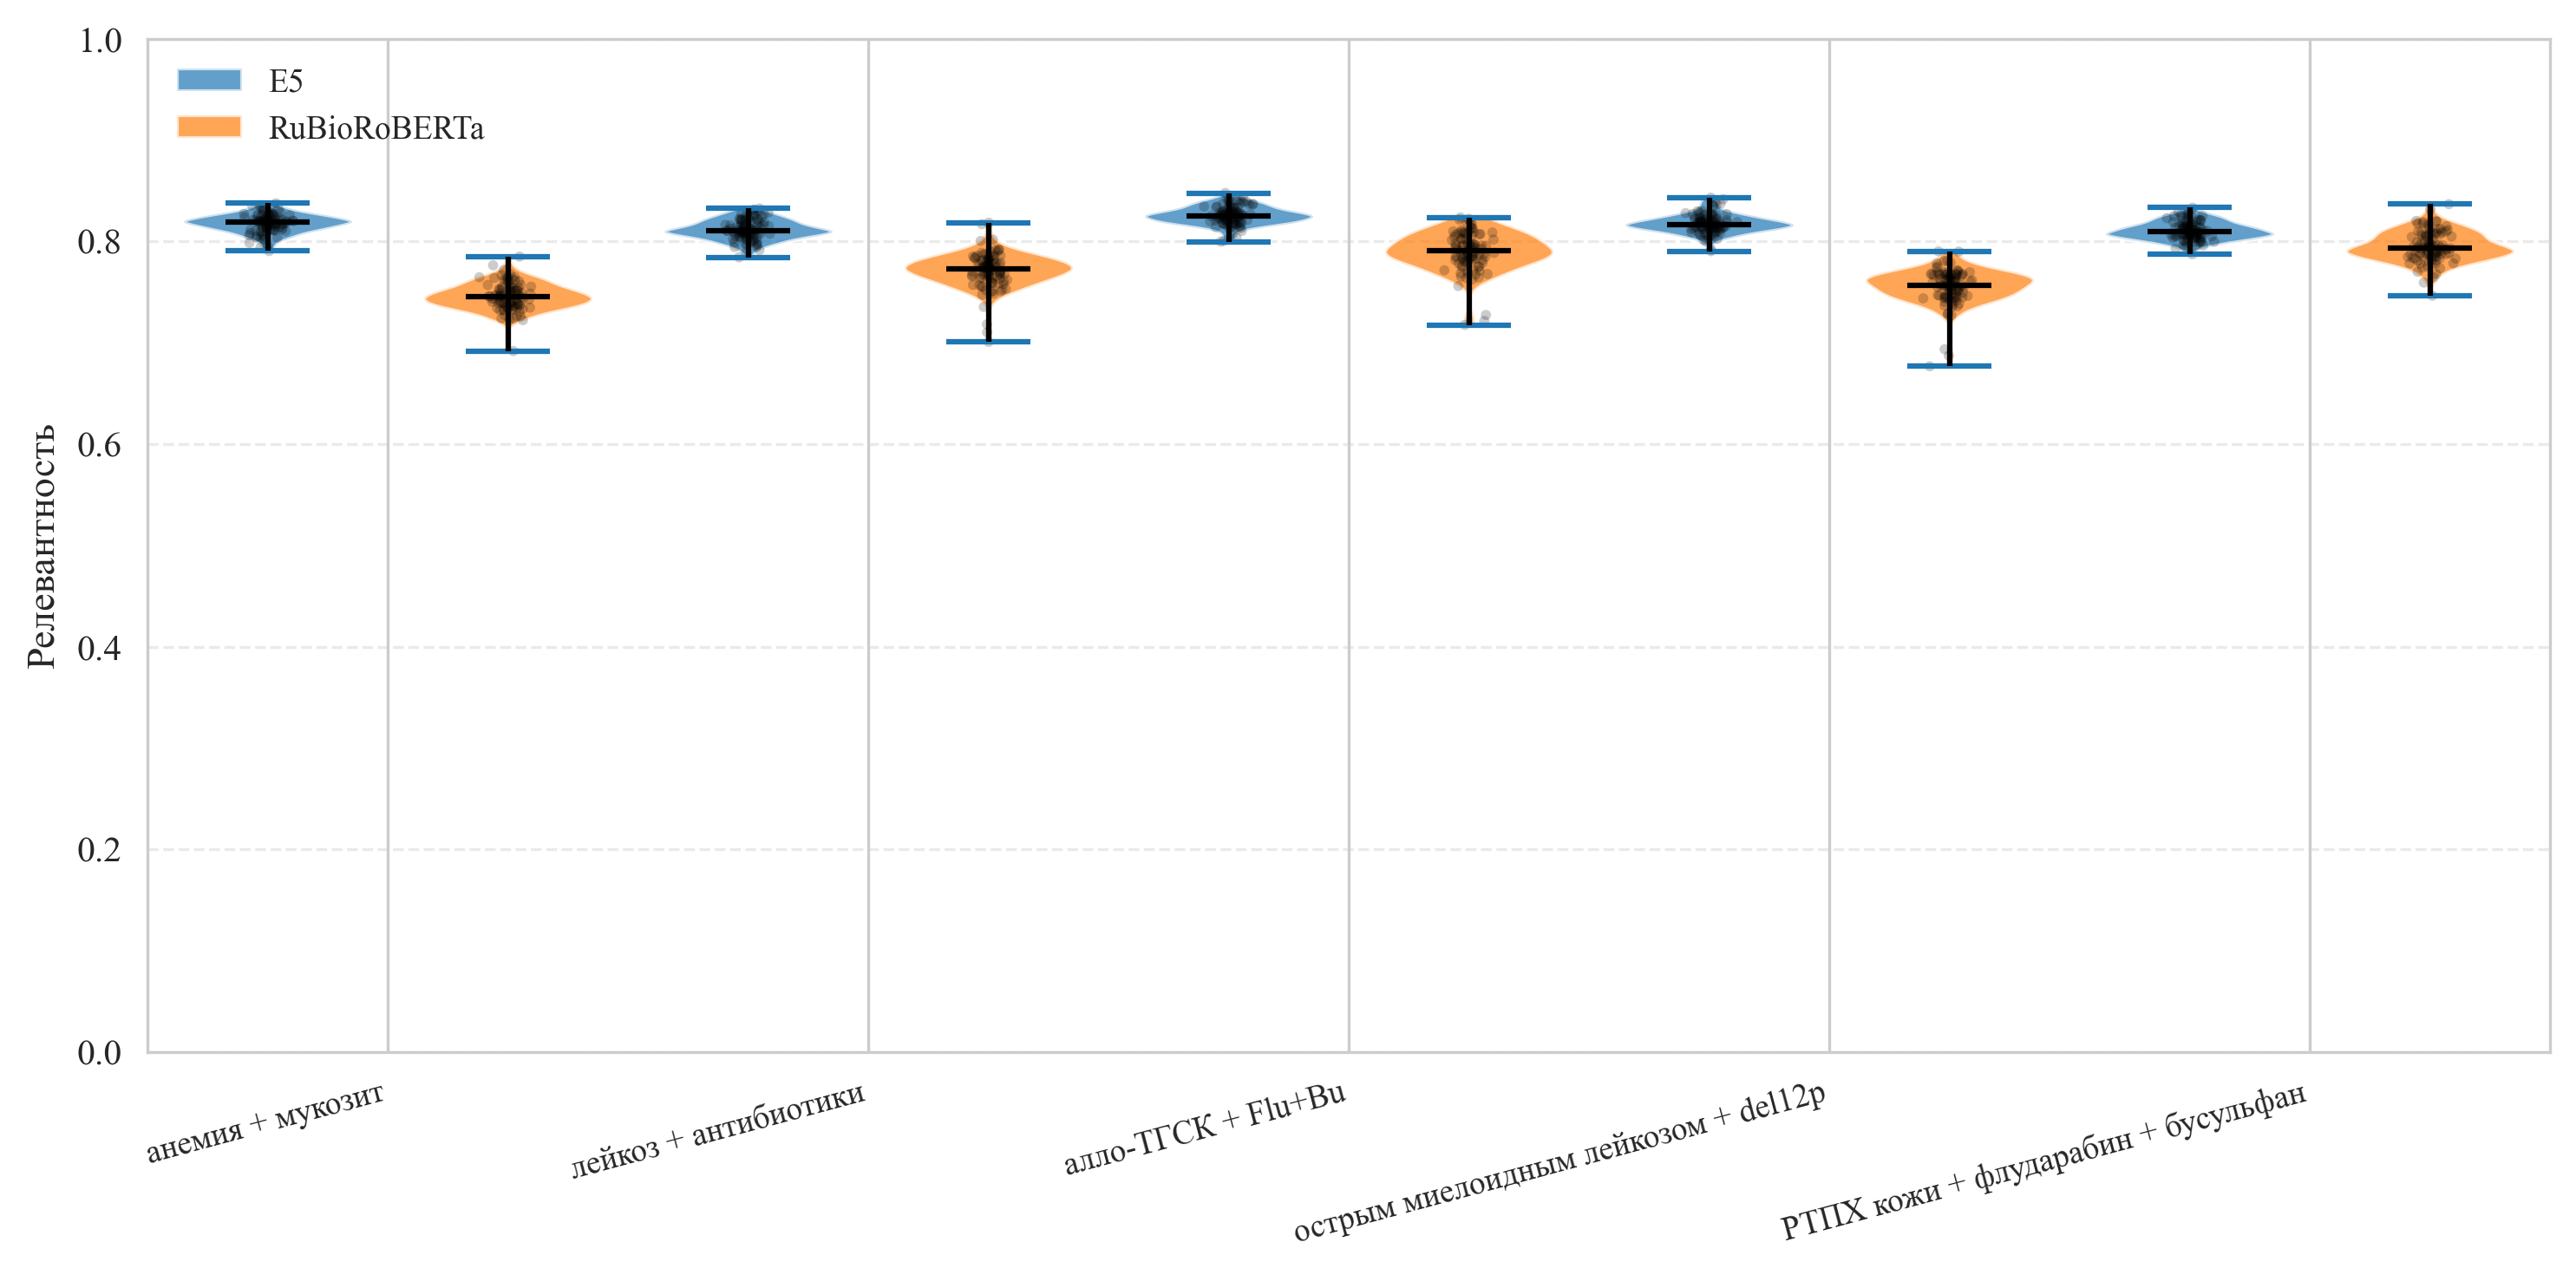

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 300


colors = {'E5': '#1f77b4', 'RuBioRoBERTa': '#ff7f0e'}


fig, ax = plt.subplots(figsize=(10, 5))


positions = []
labels = []
offset = 0
for i, qname in enumerate(query_names_short):
    positions.append(1 + 2*i)      # позиция для E5
    positions.append(2 + 2*i)      # позиция для RuBioRoBERTa
    labels.append(qname)
    labels.append('')

all_data = []
for i in range(len(query_names_short)):
    scores_e5 = [s for s in rag_e5_scores[i] if not np.isnan(s)]
    scores_rubio = [s for s in rag_rubioroberta_scores[i] if not np.isnan(s)]
    all_data.append(scores_e5)
    all_data.append(scores_rubio)

parts = ax.violinplot(all_data, positions=positions, showmeans=False, showmedians=True, widths=0.7)

for i, method in enumerate(['E5', 'RuBioRoBERTa'] * len(query_names_short)):
    parts['bodies'][i].set_facecolor(colors[method])
    parts['bodies'][i].set_alpha(0.7)
parts['cbars'].set_color('black')
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

for i in range(len(all_data)):
    x_pos = positions[i]
    scores = all_data[i]
    x_jitter = np.random.normal(x_pos, 0.04, size=len(scores))
    ax.scatter(x_jitter, scores, alpha=0.2, s=8, color='black', edgecolor='none')

ax.set_xticks([1.5 + 2*i for i in range(len(query_names_short))])
ax.set_xticklabels(query_names_short, rotation=15, ha='right', fontsize=9)
ax.set_xlim(0.5, positions[-1] + 0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('Релевантность', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['E5'], alpha=0.7, label='E5'),
                   Patch(facecolor=colors['RuBioRoBERTa'], alpha=0.7, label='RuBioRoBERTa')]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

#plt.title('Распределение релевантности: эмбеддинговые методы', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('violin_embeddings_compact.png', dpi=300)
plt.show()

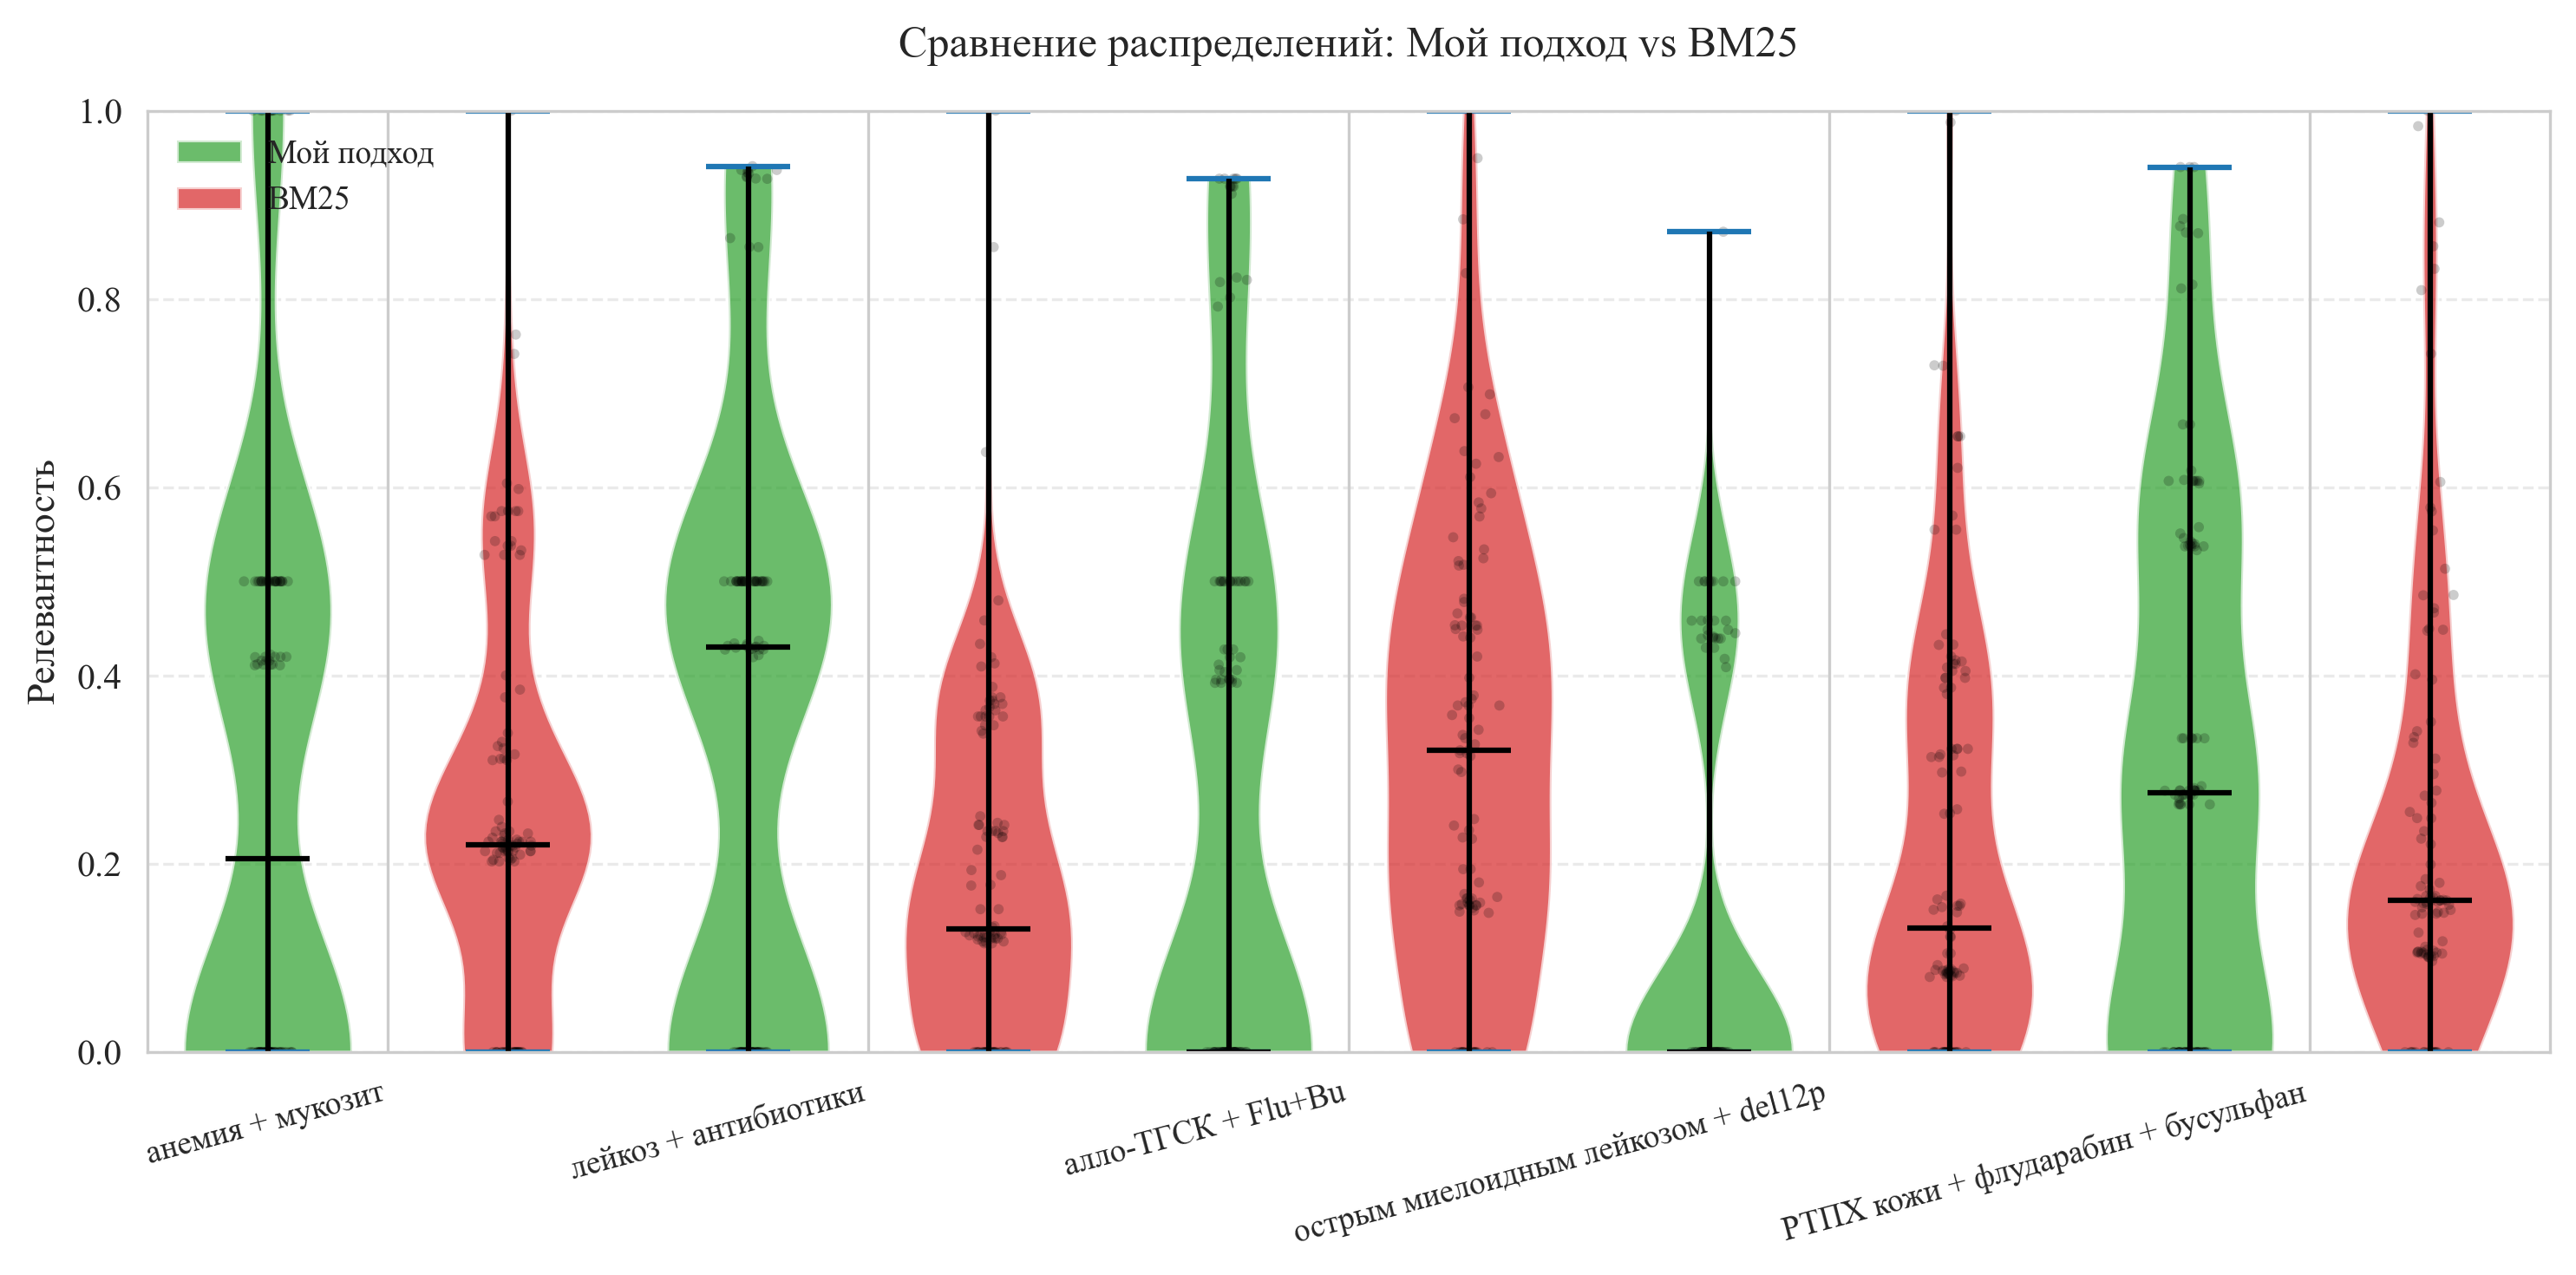

In [ ]:

my_data = []     
bm_data = []
for i in range(5):
    scores_my = [s for s in my_scores[i] if not np.isnan(s)]
    scores_bm = [s for s in bm_scores[i] if not np.isnan(s)]
    my_data.append(scores_my)
    bm_data.append(scores_bm)


colors2 = {'My': '#2ca02c', 'BM25': '#d62728'}


positions2 = []
for i in range(5):
    positions2.append(1 + 2*i)   # My
    positions2.append(2 + 2*i)   # BM25

all_data2 = []
for i in range(5):
    all_data2.append(my_data[i])
    all_data2.append(bm_data[i])

fig2, ax2 = plt.subplots(figsize=(10, 5))
parts2 = ax2.violinplot(all_data2, positions=positions2, showmeans=False, showmedians=True, widths=0.7)

for i, method in enumerate(['My', 'BM25'] * 5):
    parts2['bodies'][i].set_facecolor(colors2[method])
    parts2['bodies'][i].set_alpha(0.7)
parts2['cbars'].set_color('black')
parts2['cmedians'].set_color('black')
parts2['cmedians'].set_linewidth(1.5)

# Точки
for i in range(len(all_data2)):
    x_pos = positions2[i]
    scores = all_data2[i]
    x_jitter = np.random.normal(x_pos, 0.04, size=len(scores))
    ax2.scatter(x_jitter, scores, alpha=0.2, s=8, color='black', edgecolor='none')

ax2.set_xticks([1.5 + 2*i for i in range(5)])
ax2.set_xticklabels(query_names_short, rotation=15, ha='right', fontsize=9)
ax2.set_xlim(0.5, positions2[-1] + 0.5)
ax2.set_ylim(0, 1)
ax2.set_ylabel('Релевантность', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

legend_elements2 = [Patch(facecolor=colors2['My'], alpha=0.7, label='Мой подход'),
                    Patch(facecolor=colors2['BM25'], alpha=0.7, label='BM25')]
ax2.legend(handles=legend_elements2, loc='upper left', frameon=False)

plt.title('Сравнение распределений: Мой подход vs BM25', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('violin_my_vs_bm25_compact.png', dpi=300)
plt.show()

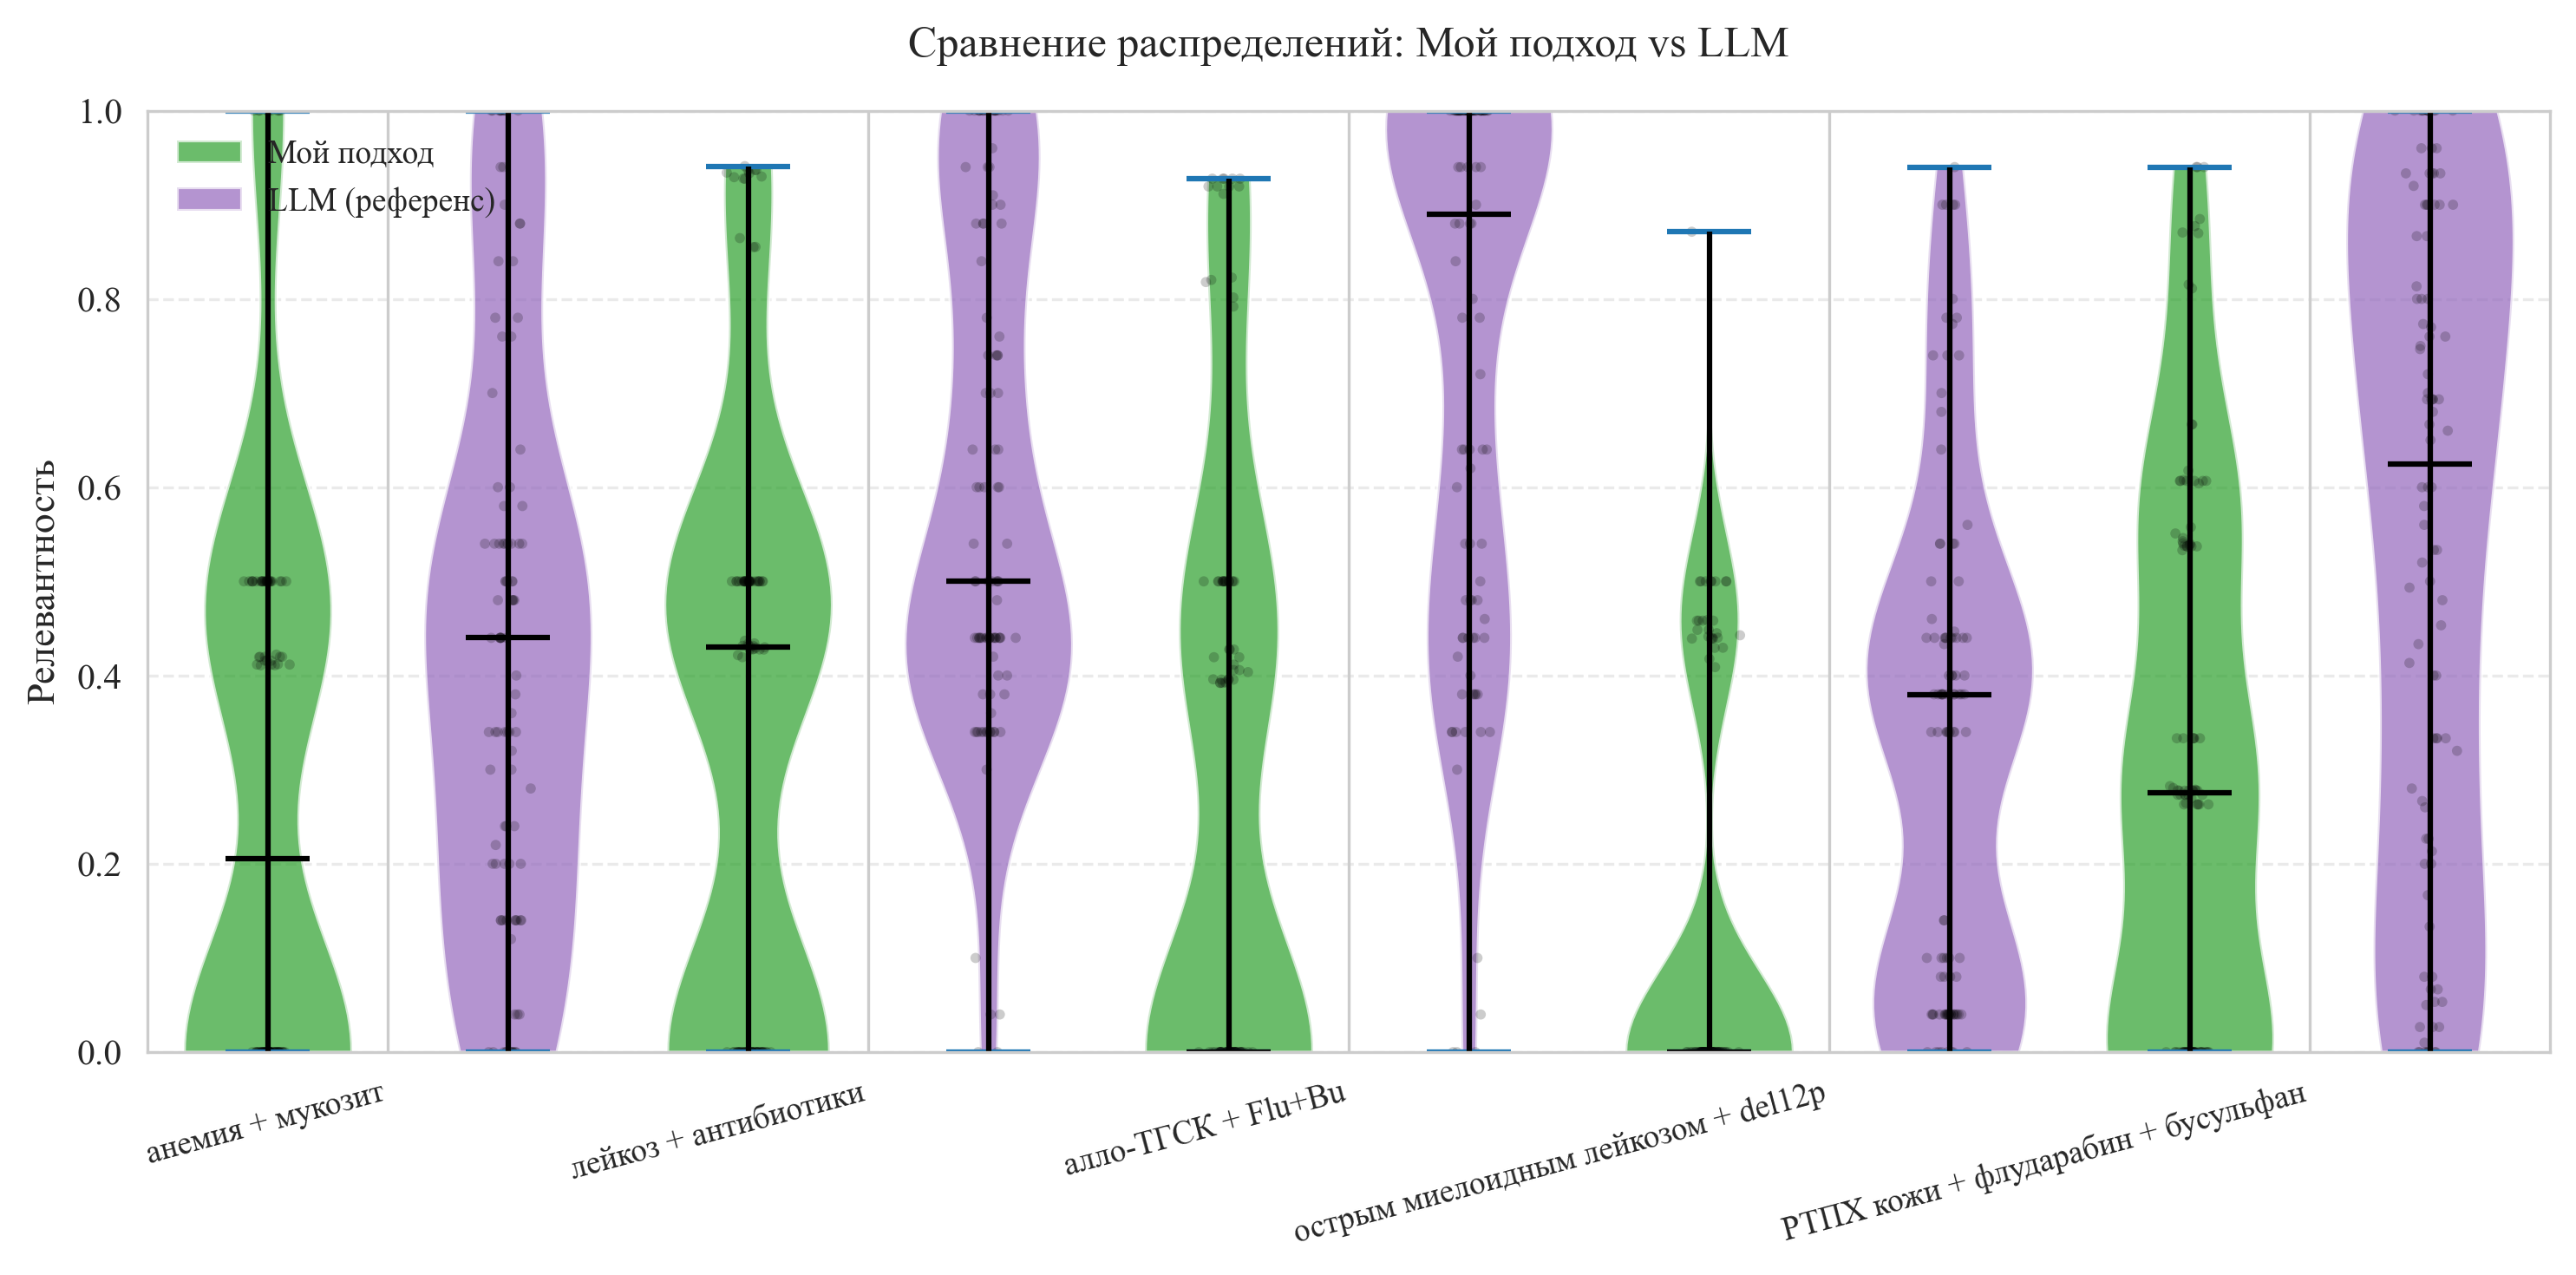

In [ ]:

my_data = []     
llm_data = []     
for i in range(len(query_names_short)):
    scores_my = [s for s in my_scores[i] if not np.isnan(s)]
    scores_llm = [s for s in gt_scores[i] if not np.isnan(s)]
    my_data.append(scores_my)
    llm_data.append(scores_llm)

# Цвета
colors3 = {'My': '#2ca02c', 'LLM': '#9467bd'}

# Позиции скрипок
positions3 = []
for i in range(len(query_names_short)):
    positions3.append(1 + 2*i)   # My
    positions3.append(2 + 2*i)   # LLM

all_data3 = []
for i in range(len(query_names_short)):
    all_data3.append(my_data[i])
    all_data3.append(llm_data[i])

fig3, ax3 = plt.subplots(figsize=(10, 5))
parts3 = ax3.violinplot(all_data3, positions=positions3, showmeans=False, showmedians=True, widths=0.7)

for i, method in enumerate(['My', 'LLM'] * len(query_names_short)):
    parts3['bodies'][i].set_facecolor(colors3[method])
    parts3['bodies'][i].set_alpha(0.7)
parts3['cbars'].set_color('black')
parts3['cmedians'].set_color('black')
parts3['cmedians'].set_linewidth(1.5)

for i in range(len(all_data3)):
    x_pos = positions3[i]
    scores = all_data3[i]
    x_jitter = np.random.normal(x_pos, 0.04, size=len(scores))
    ax3.scatter(x_jitter, scores, alpha=0.2, s=8, color='black', edgecolor='none')

ax3.set_xticks([1.5 + 2*i for i in range(len(query_names_short))])
ax3.set_xticklabels(query_names_short, rotation=15, ha='right', fontsize=9)
ax3.set_xlim(0.5, positions3[-1] + 0.5)
ax3.set_ylim(0, 1)
ax3.set_ylabel('Релевантность', fontsize=11)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

legend_elements3 = [Patch(facecolor=colors3['My'], alpha=0.7, label='Мой подход'),
                    Patch(facecolor=colors3['LLM'], alpha=0.7, label='LLM (референс)')]
ax3.legend(handles=legend_elements3, loc='upper left', frameon=False)

plt.title('Сравнение распределений: Мой подход vs LLM', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('violin_my_vs_llm_compact.png', dpi=300)
plt.show()